# BITS Pilani WILP — Deep Reinforcement Learning
###Assignment 1 - Part 1: Multi-Armed Bandit


**Group** : 87

**Problem** : Adaptive Treatment Recommendation System

**Filename** : Team 87 — MAB.pdf

**Team Members**
* RAHUL KHANNA D - 2025ab05245
* AJIT SUBRAMANIAM V - 2025aa05930
* CHANDRA SHEKHAR AZAD - 2025aa05506
* Sathish T K - 2025ab05106
* VINOTH K R - 2025aa05928


## Section 1 — Imports, Seeds & Group Configuration

In [3]:
from datetime import datetime
import socket
import os

print("=" * 60)
print("Execution Timestamp :", datetime.now())
print("VM Hostname         :", socket.gethostname())

try:
    print("VM User             :", os.getlogin())
except:
    print("VM User             : Not Available")

print("=" * 60)

Execution Timestamp : 2026-06-08 00:06:31.390575
VM Hostname         : 2025ab05245
VM User             : Not Available


In [4]:
# Import std libraries
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Group number
G = 87

# Set random seeds for repeatability
random.seed(G)
np.random.seed(G)

print("Group Number : ",G)
print(f"Seeds set    : random.seed({G}), numpy.random.seed({G})")


Group Number :  87
Seeds set    : random.seed(87), numpy.random.seed(87)


## Task 1 — Dataset Design
Generate synthetic patient-treatment dataset for Group 87.
Formula derivations:
- K = (G mod 3) + 5
- P_i = 0.4 + ((G + i) mod 6) x 0.07
- Severity = (patient_id mod 5) + 1
- UtilityScore = clinical_outcome x (1 − Severity/10)


In [6]:
def compute_parameters(G):
    # Calculate # of medicines and their hidden success probabilities with 𝐾=(𝐺 𝑚𝑜𝑑 3)+5
    K = (G % 3) + 5
    probs = [0.4 + ((G + i) % 6) * 0.07 for i in range(K)] # Hidden Prob
    return K, probs

def generate_patient_dataset(n=1000):
    # Create 1000 patients with a severity score cycling from 1 to 5
    ids = list(range(n))
    severities = [(pid % 5) + 1 for pid in ids]
    return pd.DataFrame({"patient_id": ids, "severity_score": severities})

def simulate_treatment(patient_row, medicine, hidden_probs):
    p               = hidden_probs[medicine]
    outcome         = int(np.random.rand() < p)       # 1 = recovered, 0 = not
    severity        = patient_row["severity_score"]
    utility         = outcome * (1 - severity / 10.0) # reward decreases with severity
    return outcome, utility

# Compute group parameters
K, hidden_probs = compute_parameters(G)

print(f"Group G = {G}")
print(f"Number of Medicines K = {K}")
print()
print("Hidden Success Probabilities:")
for i, p in enumerate(hidden_probs):
    tag = "  <-- OPTIMAL" if p == max(hidden_probs) else ""
    print(f"  Medicine {i}: P = {p:.4f}{tag}")

print(f"\nTrue Best Medicine: {int(np.argmax(hidden_probs))} (P = {max(hidden_probs):.4f})")

# Generate the patient dataset
base_df = generate_patient_dataset()
print("\nFirst 10 Patient Records:")
print(base_df.head(10).to_string(index=False))
print(f"\nTotal Patients : {len(base_df)}")
print(f"Severity Counts: {base_df['severity_score'].value_counts().sort_index().to_dict()}")


Group G = 87
Number of Medicines K = 5

Hidden Success Probabilities:
  Medicine 0: P = 0.6100
  Medicine 1: P = 0.6800
  Medicine 2: P = 0.7500  <-- OPTIMAL
  Medicine 3: P = 0.4000
  Medicine 4: P = 0.4700

True Best Medicine: 2 (P = 0.7500)

First 10 Patient Records:
 patient_id  severity_score
          0               1
          1               2
          2               3
          3               4
          4               5
          5               1
          6               2
          7               3
          8               4
          9               5

Total Patients : 1000
Severity Counts: {1: 200, 2: 200, 3: 200, 4: 200, 5: 200}


## Task 2 — Immediate Exploitation Strategy

**Policy:** Test each medicine 10 times -> exploit the one with highest observed success rate.


In [8]:
# Immediate Exploitation Strategy
def greedy_exploitation(base_df, hidden_probs, K, warm_up=10):
    df = base_df.copy()
    df["assigned_medicine"] = -1
    df["clinical_outcome"]  = 0
    df["utility_score"]     = 0.0

    counts    = [0] * K   # how many times each medicine was tried
    successes = [0] * K   # how many successful recoveries per medicine

    total_reward       = 0.0
    cumulative_rewards = []

    for i in range(len(df)):
        row = df.iloc[i]

        if i < K * warm_up:
            # Warm-up phase: cycle through all medicines equally
            medicine = i % K
        else:
            # Exploit phase: pick the medicine with the best success rate
            rates    = [successes[m] / counts[m] if counts[m] > 0 else 0.0 for m in range(K)]
            medicine = int(np.argmax(rates))

        outcome, utility = simulate_treatment(row, medicine, hidden_probs)

        counts[medicine]    += 1
        successes[medicine] += outcome

        df.at[i, "assigned_medicine"] = medicine
        df.at[i, "clinical_outcome"]  = outcome
        df.at[i, "utility_score"]     = utility

        total_reward += utility
        cumulative_rewards.append(total_reward)

    # Print results
    rates = [successes[m] / counts[m] if counts[m] > 0 else 0.0 for m in range(K)]
    best  = int(np.argmax(rates))
    print("Task 2 - Greedy Strategy Results")
    print(f"  Final Cumulative Reward  : {total_reward:.4f}")
    print(f"  Times Each Medicine Used : {counts}")
    print(f"  Observed Success Rates   : {[round(r, 3) for r in rates]}")
    print(f"  Best Medicine Found      : {best}")
    print(f"  True Best Medicine       : {int(np.argmax(hidden_probs))}")

    return df, cumulative_rewards

np.random.seed(G)
greedy_df, greedy_rewards = greedy_exploitation(base_df, hidden_probs, K)

# Show a few rows of the result
print("\nSample Output (first 5 patients + first exploit patient):")
sample = pd.concat([greedy_df.head(5), greedy_df.iloc[[K * 10]]])

print("\nFirst 10 Dataset Rows After Greedy:")

print(
    greedy_df[
        [
            "patient_id",
            "severity_score",
            "assigned_medicine",
            "clinical_outcome",
            "utility_score"
        ]
    ].head(10)
)


Task 2 - Greedy Strategy Results
  Final Cumulative Reward  : 518.9000
  Times Each Medicine Used : [10, 16, 954, 10, 10]
  Observed Success Rates   : [0.3, 0.625, 0.753, 0.5, 0.5]
  Best Medicine Found      : 2
  True Best Medicine       : 2

Sample Output (first 5 patients + first exploit patient):

First 10 Dataset Rows After Greedy:
   patient_id  severity_score  assigned_medicine  clinical_outcome  \
0           0               1                  0                 0   
1           1               2                  1                 0   
2           2               3                  2                 0   
3           3               4                  3                 1   
4           4               5                  4                 1   
5           5               1                  0                 0   
6           6               2                  1                 1   
7           7               3                  2                 1   
8           8               4  

## Task 3 — Controlled Clinical Trial Strategy

**Policy:** With probability ε explore (random medicine), with probability 1-ε exploit (best so far).

Simulates a clinical setting where most patients get the current best treatment, but a controlled fraction are enrolled in exploratory trials. Tested at ε ∈ {1%, 10%, 50%}.


In [10]:
# Epsilon-Greedy Strategy

def epsilon_greedy(base_df, hidden_probs, K, epsilon=0.10):
    df = base_df.copy()
    df["assigned_medicine"] = -1
    df["clinical_outcome"] = 0
    df["utility_score"] = 0.0

    counts = [0] * K
    successes = [0] * K

    total_reward = 0.0
    cumulative_rewards = []

    for i in range(len(df)):
        row = df.iloc[i]

        if np.random.rand() < epsilon or all(c == 0 for c in counts):
            medicine = np.random.randint(0, K)
        else:
            rates = [successes[m] / counts[m] if counts[m] > 0 else 0.0 for m in range(K)]
            medicine = int(np.argmax(rates))

        outcome, utility = simulate_treatment(row, medicine, hidden_probs)

        counts[medicine] += 1
        successes[medicine] += outcome

        df.at[i, "assigned_medicine"] = medicine
        df.at[i, "clinical_outcome"] = outcome
        df.at[i, "utility_score"] = utility

        total_reward += utility
        cumulative_rewards.append(total_reward)

    return df, cumulative_rewards, counts, successes


epsilon_configs = [(0.10, "10%"), (0.01, "1%"), (0.50, "50%")]
eps_results = {}

print("Task 3 - Epsilon-Greedy Results")
print(f"{'Epsilon':>10} {'Final Reward':>15} {'Best Found':>12}")
print("-" * 50)

for eps, label in epsilon_configs:

    np.random.seed(G)

    df_e, rew_e, cnt_e, suc_e = epsilon_greedy(
        base_df,
        hidden_probs,
        K,
        epsilon=eps
    )

    eps_results[label] = {
        "df": df_e,
        "rewards": rew_e,
        "counts": cnt_e,
        "successes": suc_e
    }

    best = int(
        np.argmax(
            [
                suc_e[m] / cnt_e[m]
                if cnt_e[m] > 0 else 0
                for m in range(K)
            ]
        )
    )

    print(f"{label:>10} {rew_e[-1]:>15.4f} {best:>12}")

    print(f"\nSample rows for epsilon={label}")
    print(
        df_e[
            [
                "patient_id",
                "severity_score",
                "assigned_medicine",
                "clinical_outcome",
                "utility_score"
            ]
        ].head(5)
    )

    print("-" * 80)

print("\nAnalysis:")
print("epsilon=1%  : Almost always exploits and may lock onto a suboptimal medicine.")
print("epsilon=10% : Good balance between exploration and exploitation.")
print("epsilon=50% : Excessive exploration reduces overall reward.")


Task 3 - Epsilon-Greedy Results
   Epsilon    Final Reward   Best Found
--------------------------------------------------
       10%        505.9000            2

Sample rows for epsilon=10%
   patient_id  severity_score  assigned_medicine  clinical_outcome  \
0           0               1                  3                 1   
1           1               2                  3                 0   
2           2               3                  3                 0   
3           3               4                  0                 0   
4           4               5                  3                 0   

   utility_score  
0            0.9  
1            0.0  
2            0.0  
3            0.0  
4            0.0  
--------------------------------------------------------------------------------
        1%        394.9000            0

Sample rows for epsilon=1%
   patient_id  severity_score  assigned_medicine  clinical_outcome  \
0           0               1                  3      

## Task 4 — Confidence-Based Strategy - UCB1


In [12]:
# UCB1 Strategy
def ucb1_strategy(base_df, hidden_probs, K):

    # Create a fresh copy of dataset
    df = base_df.copy()

    df["assigned_medicine"] = -1
    df["clinical_outcome"] = 0
    df["utility_score"] = 0.0

    # Number of pulls per medicine
    counts = [0] * K

    # Successful recoveries per medicine
    successes = [0] * K

    # Estimated success probability
    mean_success = [0.0] * K

    total_reward = 0.0

    cumulative_rewards = []

    # -------------------------------------------------
    # Initialisation:
    # Pull each medicine once
    # -------------------------------------------------

    for t in range(1, len(df) + 1):

        row = df.iloc[t - 1]

        if t <= K:

            medicine = t - 1

        else:

            ucb_scores = []

            for m in range(K):

                exploration_bonus = np.sqrt(
                    (2 * np.log(t)) / counts[m]
                )

                score = mean_success[m] + exploration_bonus

                ucb_scores.append(score)

            medicine = int(np.argmax(ucb_scores))

        outcome, utility = simulate_treatment(
            row,
            medicine,
            hidden_probs
        )

        # ---------------------------------------------
        # Update Bandit Statistics using Outcome
        # ---------------------------------------------

        counts[medicine] += 1

        successes[medicine] += outcome

        mean_success[medicine] = (
            successes[medicine] / counts[medicine]
        )

        # ---------------------------------------------
        # Store dataset values
        # ---------------------------------------------

        df.at[t - 1, "assigned_medicine"] = medicine
        df.at[t - 1, "clinical_outcome"] = outcome
        df.at[t - 1, "utility_score"] = utility

        # ---------------------------------------------
        # Reward Tracking
        # ---------------------------------------------

        total_reward += utility

        cumulative_rewards.append(total_reward)

    best = int(np.argmax(mean_success))

    print("Task 4 - UCB1 Strategy Results")

    print(
        f"Final Cumulative Reward : "
        f"{total_reward:.4f}"
    )

    print(
        f"Times Each Medicine Used : "
        f"{counts}"
    )

    print(
        f"Observed Success Rates : "
        f"{[round(x,4) for x in mean_success]}"
    )

    print(
        f"Best Medicine Found : {best}"
    )

    print(
        f"True Best Medicine : "
        f"{int(np.argmax(hidden_probs))}"
    )

    return (
        df,
        cumulative_rewards,
        counts,
        mean_success
    )

np.random.seed(G)

ucb_df, ucb_rewards, ucb_counts, ucb_success_rates = (
    ucb1_strategy(
        base_df,
        hidden_probs,
        K
    )
)

print("\nFirst 10 Rows After UCB1:")

print(
    ucb_df[
        [
            "patient_id",
            "severity_score",
            "assigned_medicine",
            "clinical_outcome",
            "utility_score"
        ]
    ].head(10)
)

# Show how often each medicine was selected
print("\nMedicine Selection Counts (UCB1):")
for m in range(K):

    bar = "#" * (ucb_counts[m] // 10)

    print(
        f"Medicine {m} "
        f"(True P={hidden_probs[m]:.2f}) | "
        f"Selected {ucb_counts[m]} times | "
        f"Estimated Success={ucb_success_rates[m]:.3f} "
        f"{bar}"
    )

Task 4 - UCB1 Strategy Results
Final Cumulative Reward : 472.1000
Times Each Medicine Used : [94, 302, 482, 53, 69]
Observed Success Rates : [0.5319, 0.702, 0.7469, 0.3962, 0.4638]
Best Medicine Found : 2
True Best Medicine : 2

First 10 Rows After UCB1:
   patient_id  severity_score  assigned_medicine  clinical_outcome  \
0           0               1                  0                 0   
1           1               2                  1                 0   
2           2               3                  2                 0   
3           3               4                  3                 1   
4           4               5                  4                 1   
5           5               1                  3                 0   
6           6               2                  4                 0   
7           7               3                  0                 0   
8           8               4                  1                 0   
9           9               5                

## Task 5 — Comparative Analysis

Visual comparison of all 5 strategies across 1000 patients, plus a 4-question analysis.


Task 2 - Greedy Strategy Results
  Final Cumulative Reward  : 518.9000
  Times Each Medicine Used : [10, 16, 954, 10, 10]
  Observed Success Rates   : [0.3, 0.625, 0.753, 0.5, 0.5]
  Best Medicine Found      : 2
  True Best Medicine       : 2


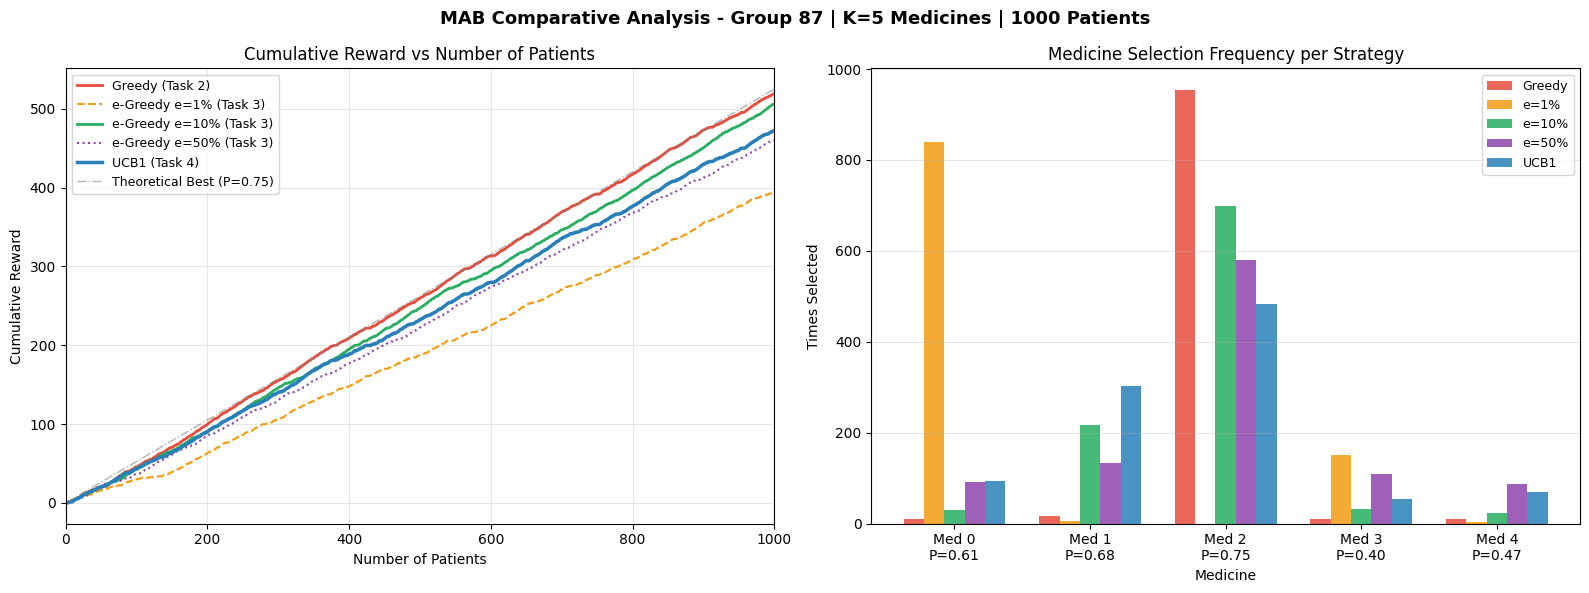

In [14]:
# Analysis

def plot_comparison(greedy_rewards, eps_results, ucb_rewards, hidden_probs, K, greedy_df):
    patients = list(range(1, 1001))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("MAB Comparative Analysis - Group 87 | K=5 Medicines | 1000 Patients",
                 fontsize=13, fontweight="bold")

    # --- Left Plot: Cumulative Reward over time ---
    ax1 = axes[0]
    ax1.plot(patients, greedy_rewards,                color="#E74C3C", lw=2.0, label="Greedy (Task 2)")
    ax1.plot(patients, eps_results["1%"]["rewards"],  color="#F39C12", lw=1.5, ls="--", label="e-Greedy e=1% (Task 3)")
    ax1.plot(patients, eps_results["10%"]["rewards"], color="#27AE60", lw=2.0, label="e-Greedy e=10% (Task 3)")
    ax1.plot(patients, eps_results["50%"]["rewards"], color="#8E44AD", lw=1.5, ls=":", label="e-Greedy e=50% (Task 3)")
    ax1.plot(patients, ucb_rewards,                   color="#2980B9", lw=2.5, label="UCB1 (Task 4)")

    # Theoretical best possible reward line
    best_p     = max(hidden_probs)
    avg_sev    = np.mean([(pid % 5 + 1) for pid in range(1000)])
    opt_reward = best_p * (1 - avg_sev / 10.0)
    ax1.plot(patients, [opt_reward * t for t in patients],
             color="gray", lw=1.0, ls="-.", alpha=0.6, label=f"Theoretical Best (P={best_p:.2f})")

    ax1.set_xlabel("Number of Patients")
    ax1.set_ylabel("Cumulative Reward")
    ax1.set_title("Cumulative Reward vs Number of Patients")
    ax1.legend(fontsize=9, loc="upper left")
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 1000)

    # --- Right Plot: How often each medicine was selected ---
    ax2  = axes[1]
    x, w = np.arange(K), 0.15
    strategies = {
        "Greedy": ([greedy_df["assigned_medicine"].tolist().count(m) for m in range(K)], "#E74C3C"),
        "e=1%":   ([eps_results["1%"]["counts"][m]  for m in range(K)], "#F39C12"),
        "e=10%":  ([eps_results["10%"]["counts"][m] for m in range(K)], "#27AE60"),
        "e=50%":  ([eps_results["50%"]["counts"][m] for m in range(K)], "#8E44AD"),
        "UCB1":   ([ucb_counts[m] for m in range(K)], "#2980B9"),
    }
    for idx, (name, (vals, color)) in enumerate(strategies.items()):
        ax2.bar(x + idx * w, vals, width=w, label=name, color=color, alpha=0.85)

    ax2.set_xlabel("Medicine")
    ax2.set_ylabel("Times Selected")
    ax2.set_title("Medicine Selection Frequency per Strategy")
    ax2.set_xticks(x + 2 * w)
    ax2.set_xticklabels([f"Med {i}\nP={hidden_probs[i]:.2f}" for i in range(K)])
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.savefig("./mab_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

# Re-run with fixed seed for clean plot
np.random.seed(G)
greedy_df2, greedy_rewards2 = greedy_exploitation(base_df, hidden_probs, K)

np.random.seed(G)
_, eps10_rew, _, _ = epsilon_greedy(base_df, hidden_probs, K, epsilon=0.10)
eps_results["10%"]["rewards"] = eps10_rew

plot_comparison(greedy_rewards, eps_results, ucb_rewards, hidden_probs, K, greedy_df)


In [15]:
# Analysis Questions and Summary

summary = {
    "Strategy": [
        "Greedy",
        "e-Greedy 1%",
        "e-Greedy 10%",
        "e-Greedy 50%",
        "UCB1"
    ],
    "Final Cumulative Reward": [
        round(greedy_rewards[-1], 4),
        round(eps_results["1%"]["rewards"][-1], 4),
        round(eps_results["10%"]["rewards"][-1], 4),
        round(eps_results["50%"]["rewards"][-1], 4),
        round(ucb_rewards[-1], 4)
    ]
}

summary_df = pd.DataFrame(summary).sort_values(
    "Final Cumulative Reward",
    ascending=False
)

summary_df.index = range(1, len(summary_df) + 1)

print("Final Reward Ranking:")
print(summary_df.to_string())

best_strategy = summary_df.iloc[0]["Strategy"]

print("\nQ1. Which strategy achieves the highest cumulative reward?")
print(f"{best_strategy} with reward = {summary_df.iloc[0]['Final Cumulative Reward']:.4f}")

print("\nQ2. Which strategy identifies the best medicine the fastest?")
print("UCB1 efficiently balances exploration and exploitation using confidence bounds.")

print("\nQ3. Which strategy has the most stable performance over time?")
print("e-Greedy (10%) generally provides smooth and consistent learning behaviour.")

print("\nQ4. Which strategy would you recommend for real hospital deployment?")
print("UCB1, because it automatically reduces exploration as evidence grows and does not require manual epsilon tuning.")

print("\nComparative Summary:")
print(
    "Greedy can achieve high reward but risks committing too early.\n"
    "e-Greedy 10% provides a practical balance between learning and performance.\n"
    "e-Greedy 50% explores excessively and sacrifices reward.\n"
    "e-Greedy 1% may converge too early to a suboptimal medicine.\n"
    "UCB1 offers a principled exploration strategy and is generally the safest recommendation."
)


Final Reward Ranking:
       Strategy  Final Cumulative Reward
1        Greedy                    518.9
2  e-Greedy 10%                    505.9
3          UCB1                    472.1
4  e-Greedy 50%                    460.1
5   e-Greedy 1%                    394.9

Q1. Which strategy achieves the highest cumulative reward?
Greedy with reward = 518.9000

Q2. Which strategy identifies the best medicine the fastest?
UCB1 efficiently balances exploration and exploitation using confidence bounds.

Q3. Which strategy has the most stable performance over time?
e-Greedy (10%) generally provides smooth and consistent learning behaviour.

Q4. Which strategy would you recommend for real hospital deployment?
UCB1, because it automatically reduces exploration as evidence grows and does not require manual epsilon tuning.

Comparative Summary:
Greedy can achieve high reward but risks committing too early.
e-Greedy 10% provides a practical balance between learning and performance.
e-Greedy 50% expl

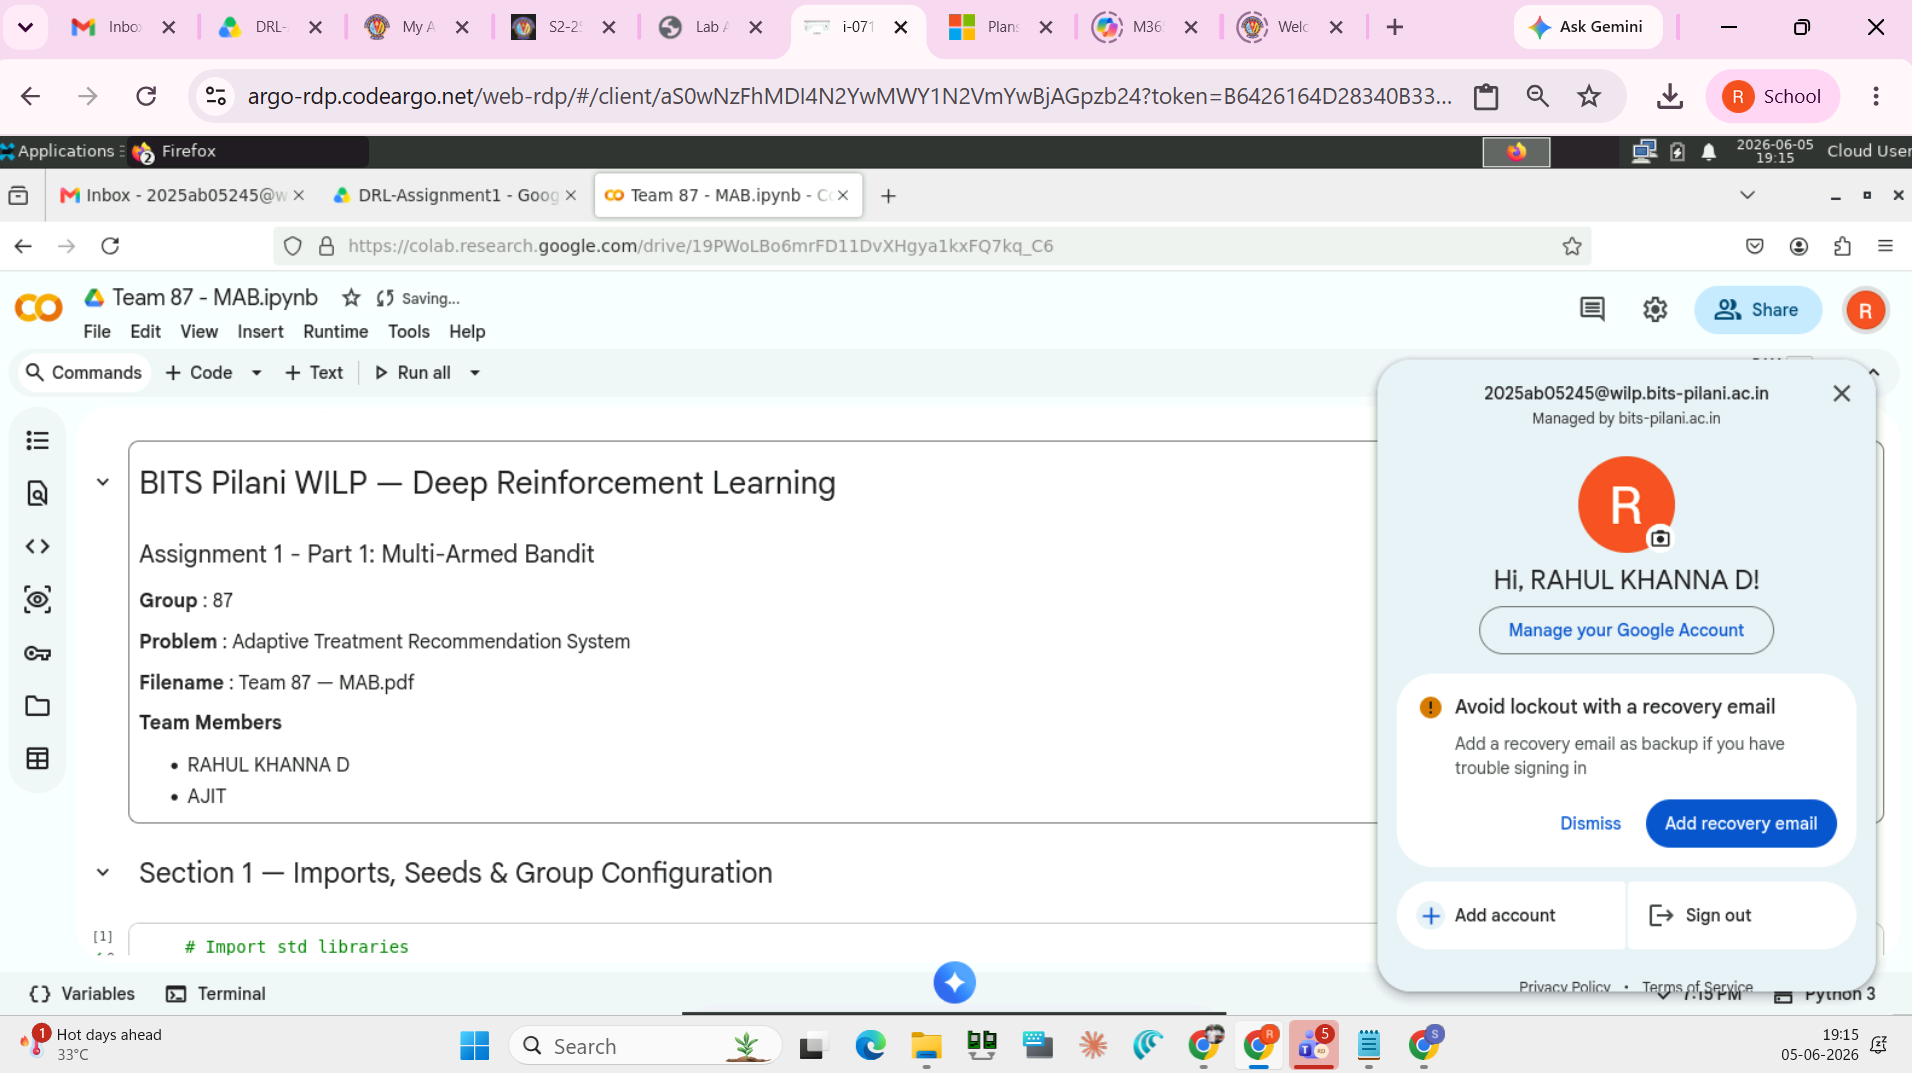

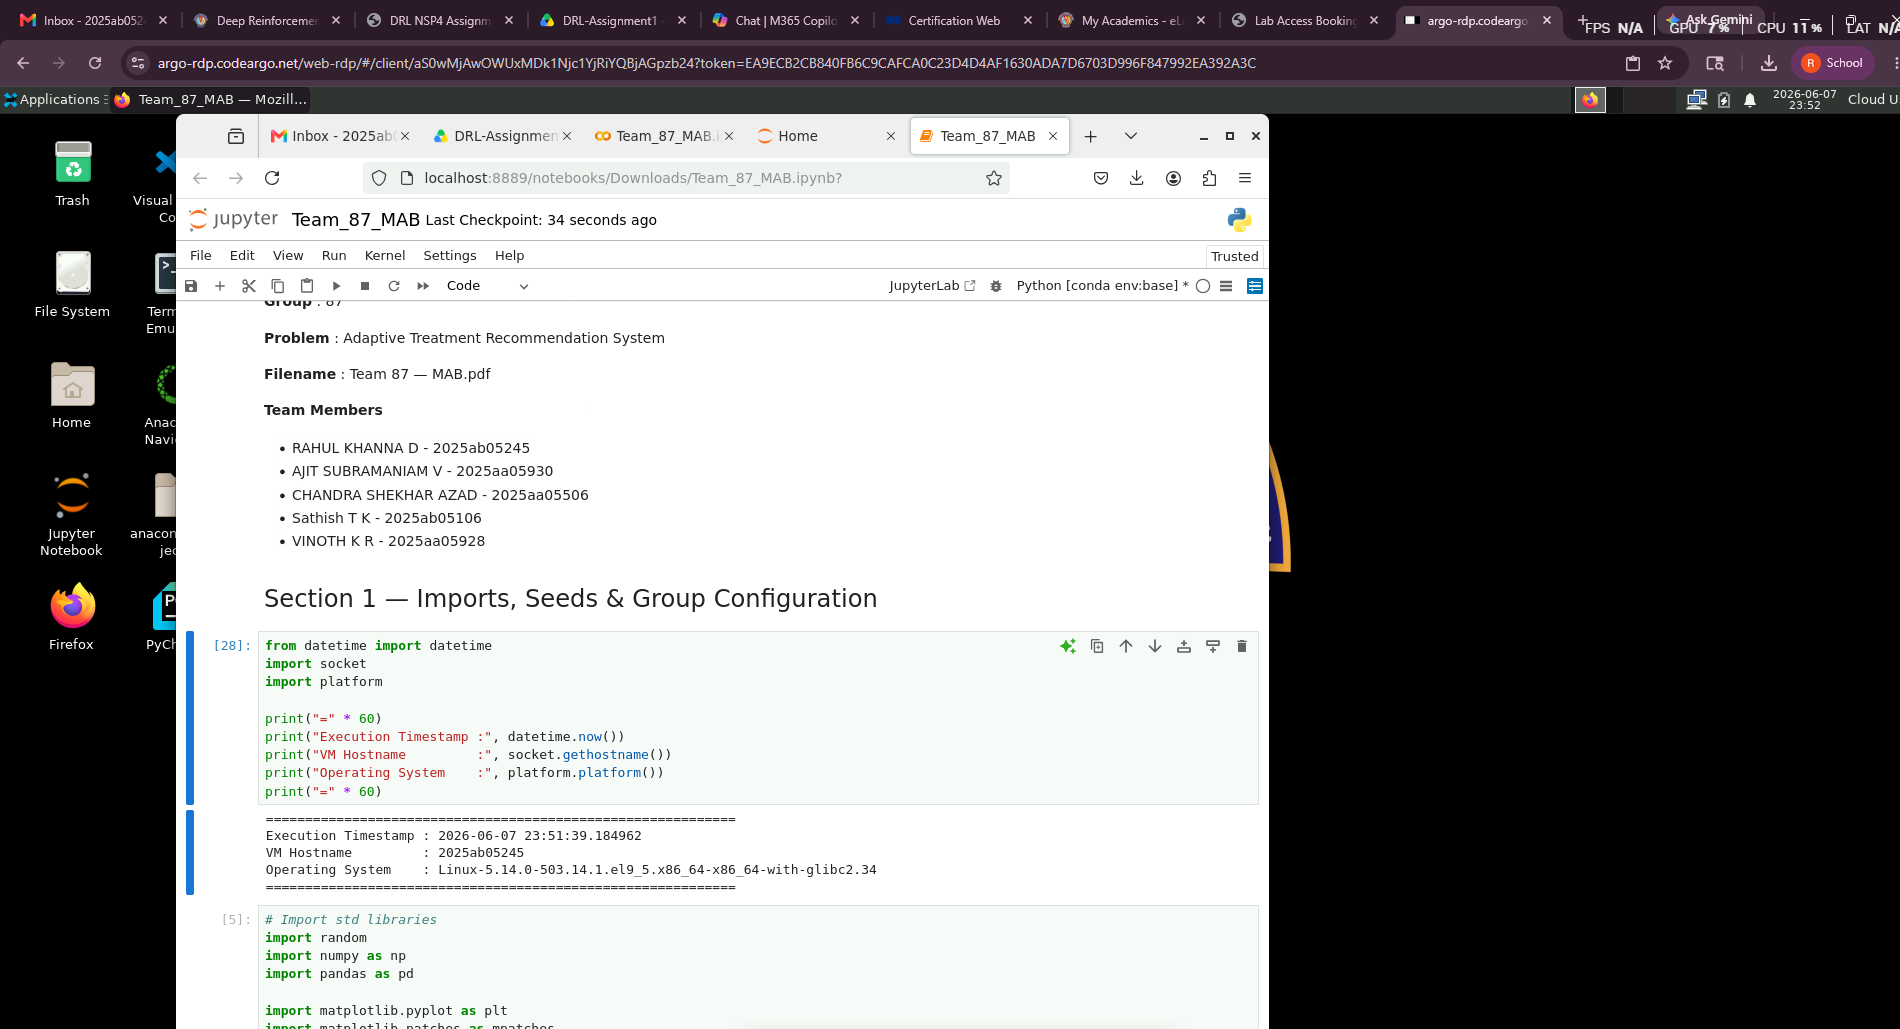